In [26]:
import networkx as nx
import osmnx as ox
import geopandas as gpd
import contextily as ctx 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Traveling Salesperson Problem
The canonical [Traveling Salesperson Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem) is stated as:
>  "Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city and returns to the origin city?"

This is generalizable to finding the shortest [Hamiltonian cycle](http://mathworld.wolfram.com/HamiltonianCycle.html) on a fully connected graph (i.e. all nodes can be reached from all other nodes).

This problem is [NP-hard](https://en.wikipedia.org/wiki/P_versus_NP_problem), meaning it is not possible for an algorithm to solve all instances of the problem quickly (i.e. in polynomial time). However, there are many approximate and heuristic approaches which can give reasonable solutions in shorter time.

In [27]:
place_name = 'New York City, NY, United States'
# place_roads = ox.graph_from_place(place_name)

I've already downloaded the roads for NYC and it's hosted on our file server. However, if you wanted to do it for yourself, you can uncomment the next cell. It will take a long time to run, however, since it is a big set of roads.

In [28]:
# # We can query osm for the roads
# place_roads = ox.graph_from_place(place_name)
# # save graph to file for reuse
# ox.io.save_graphml(place_roads, 'nyc_osmnx.graphml')

In [29]:
!wget https://files.bwsi-remote-sensing.net/data/nyc_osmnx.graphml

--2026-07-17 16:36:17--  https://files.bwsi-remote-sensing.net/data/nyc_osmnx.graphml
Resolving files.bwsi-remote-sensing.net (files.bwsi-remote-sensing.net)... 54.191.11.29, 54.213.237.237, 54.186.120.170, ...
Connecting to files.bwsi-remote-sensing.net (files.bwsi-remote-sensing.net)|54.191.11.29|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 366491036 (350M) [text/xml]
Saving to: ‘nyc_osmnx.graphml.2’

nyc_osmnx.graphml.2 100%[===================>] 349.51M   254MB/s    in 1.4s    

2026-07-17 16:36:18 (254 MB/s) - ‘nyc_osmnx.graphml.2’ saved [366491036/366491036]



In [30]:
# loading graph from a file. This will take a while to load.
place_roads = ox.io.load_graphml('nyc_osmnx.graphml')

In [31]:
place_roads_nodes, place_roads_edges = ox.graph_to_gdfs(place_roads)

In [58]:
place_roads_nodes

,y,x,street_count,ref,highway,geometry
osmid,,,,,,
30807314,40.790720,-73.963576,4,NaN,NaN,POINT (-73.96358 40.79072)
30978747,40.774267,-73.973425,4,NaN,NaN,POINT (-73.97342 40.77427)
30978752,40.774776,-73.974360,4,NaN,NaN,POINT (-73.97436 40.77478)
39076461,40.786409,-73.794627,3,33,motorway_junction,POINT (-73.79463 40.78641)
39076490,40.762429,-73.757091,3,31W,motorway_junction,POINT (-73.75709 40.76243)
...,...,...,...,...,...,...
11053925602,40.668650,-73.736868,4,NaN,NaN,POINT (-73.73687 40.66865)
11053925603,40.668110,-73.736124,4,NaN,NaN,POINT (-73.73612 40.66811)
11053925604,40.666457,-73.738318,4,NaN,NaN,POINT (-73.73832 40.66646)


<Axes: >

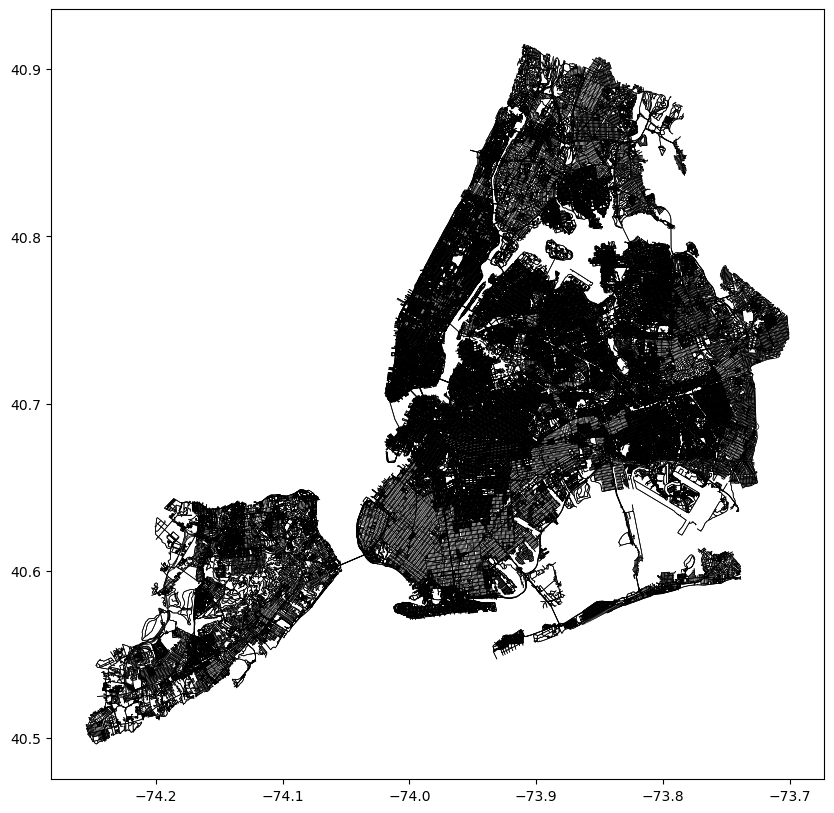

In [32]:
fig = plt.figure(figsize=[10,10])
ax = fig.add_subplot(1,1,1)
place_roads_edges.plot(ax=ax, color=[0, 0, 0], linewidth=0.5)

Let's say you wanted to do a ice cream crawl: you want to visit every ice cream shop in a city. What is the shortest route that you would take that takes you to every ice cream shop in a city and brings you back to your starting point?

In [33]:
# Get ice cream shop locations
place_ice_cream = ox.features.features_from_place(place_name, tags={"amenity": "ice_cream"})

# Projecting to Web-Mercator for more accurate centroids
place_ice_cream = place_ice_cream.to_crs("epsg:3857")

# Some of the ice cream shops return polygons instead of points, so we need to take their centroids
place_ice_cream["geometry"] = place_ice_cream.geometry.centroid

# Projecting back to lat/long
place_ice_cream = place_ice_cream.to_crs("epsg:4326")

# Display the result
print(place_ice_cream)

/opt/conda/lib/python3.11/site-packages/osmnx/features.py:294: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = gdf_place["geometry"].unary_union


                             addr:city addr:housenumber addr:postcode  \
element_type osmid                                                      
node         419360637        New York               95         10003   
             419364720        Brooklyn               81         11201   
             475485737        Brooklyn                1         11201   
             617342597        Brooklyn              341         11211   
             1109836197       New York               93         10009   
...                                ...              ...           ...   
way          280470545             NaN            52-02           NaN   
             405892188        Brooklyn             1224         11224   
             576014904             NaN              NaN           NaN   
             904169911             NaN              NaN           NaN   
             904206135   Staten Island              280         10314   

                        addr:state       addr:stre

In [34]:
place_ice_cream

addr:city addr:housenumber addr:postcode  \
element_type osmid                                                      
node         419360637        New York               95         10003   
             419364720        Brooklyn               81         11201   
             475485737        Brooklyn                1         11201   
             617342597        Brooklyn              341         11211   
             1109836197       New York               93         10009   
...                                ...              ...           ...   
way          280470545             NaN            52-02           NaN   
             405892188        Brooklyn             1224         11224   
             576014904             NaN              NaN           NaN   
             904169911             NaN              NaN           NaN   
             904206135   Staten Island              280         10314   

                        addr:state       addr:street    amenity  \
element_type osmid                                                
node         419360637          NY  East 10th Street  ice_cream   
             419364720          NY     Bergen Street  ice_cream   
             475485737          NY      Water Street  ice_cream   
             617342597          NY     Graham Avenue  ice_cream   
             1109836197         NY   East 7th Street  ice_cream   
...                            ...               ...        ...   
way          280470545         NaN      108th Street  ice_cream   
             405892188          NY       Surf Avenue  ice_cream   
             576014904         NaN               NaN  ice_cream   
             904169911         NaN               NaN  ice_cream   
             904206135          NY      Marsh Avenue  ice_cream   

                                             name  \
element_type osmid                                  
node         419360637          Sundaes and Cones   
             419364720                Van Leeuwen   
             475485737      Van Leeuwen Ice Cream   
             617342597              Uncle Louie G   
             1109836197                  Baonanas   
...                                           ...   
way          280470545   Lemon Ice King of Corona   
             405892188         Lunatics Ice Cream   
             576014904                        NaN   
             904169911              Frozen D Lite   
             904206135                     Carvel   

                                                             opening_hours  \
element_type osmid                                                           
node         419360637                                   Mo-Su 12:00-22:00   
             419364720                                   Mo-Su 11:00-24:00   
             475485737                                         11:00-23:30   
             617342597                                                 NaN   
             1109836197  Mo off; Tu off; We off; Th,Fr 16:00-00:00; Sa ...   
...                                                                    ...   
way          280470545                                                 NaN   
             405892188                                                 NaN   
             576014904                                                 NaN   
             904169911                                                 NaN   
             904206135                   Mo-Sa 11:00-22:00; Su 11:00-21:30   

                        outdoor_seating            phone  ...  \
element_type osmid                                        ...   
node         419360637            bench  +1-212-979-9398  ...   
             419364720              NaN  +1-347-763-2979  ...   
             475485737              yes              NaN  ...   
             617342597         sidewalk  +1-718-354-5777  ...   
             1109836197             NaN              NaN  ...   
...                                 ...        

In [35]:
#snaps to nearest node
ice_cream_nodes = ox.distance.nearest_nodes(place_roads, place_ice_cream.geometry.x, place_ice_cream.geometry.y)
ice_cream_nodes

[8309479610,
 10745141695,
 8262934647,
 9795356081,
 8309479529,
 7465391419,
 8262309032,
 8314977757,
 8236746391,
 7779545035,
 10039938745,
 9795044603,
 8386198042,
 9891508839,
 9897724589,
 10061553268,
 8309479210,
 10779679897,
 9883324376,
 5572434481,
 10699989886,
 8916499429,
 8679627908,
 5415926010,
 7571891035,
 10770328374,
 7465125494,
 10642847921,
 4216045841,
 9897530715,
 6417176120,
 8775287191,
 9973544297,
 42870183,
 10791214424,
 42465566,
 42468978,
 42465489,
 42465457,
 10655305018,
 6638433920,
 3891969471,
 9811007532,
 4300912707,
 8231896468,
 6369613044,
 8262308486,
 9850720011,
 4964127740,
 10165972532,
 8288270355,
 10168088481,
 9235539544,
 7137586326,
 9902312978,
 5115907032,
 8709392046,
 10650749604,
 6597498400,
 10171187069,
 9550791810,
 10743722636,
 6452901805,
 9242368788,
 8288329067,
 5396215013,
 10899767199,
 42876552,
 5487925826,
 10170640086,
 8250715772,
 8309479715,
 9242368785,
 9242380423,
 8309479271,
 9893390525,
 7570756

## Exercise
Plot the locations of the ice cream shops on the map of the roads

In [36]:
#Import library

# Make sure ice cream shops and roads use the same CRS
#place_ice_cream.nodes[ice_cream_nodes]

place_ice_cream_linear = place_ice_cream.to_crs('epsg: 3857')
place_roads_edges_linear = place_roads_edges.to_crs('epsg: 3857')
# Create figure

# fig = plt.figure()
# ax = fig.add_subplot(1,1,1)

# # Plot NYC roads at the bottom layer

# place_roads_edges_linear.plot(ax = axlinewidth = 1)


# Plot ice cream shop locations on the top layer




# Add legend



# Add title




# Remove axis for cleaner map



# Show map




<Axes: >

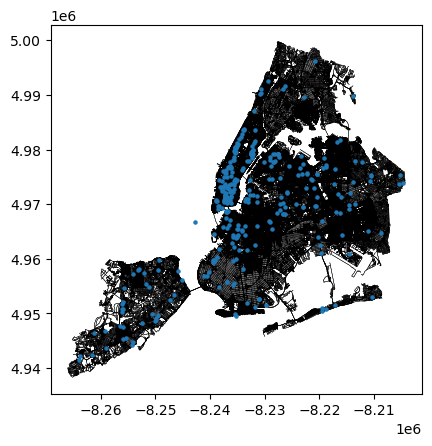

In [37]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# Plot NYC roads at the bottom layer

place_roads_edges_linear.plot(ax = ax, linewidth = 0.3, color = 'black', zorder = 1)
place_ice_cream_linear.plot(ax = ax, zorder = 2, markersize = 5)

In [38]:
#updated
ice_cream_nodes_copy = ice_cream_nodes
#only first 30 for speed
ice_cream_nodes = ice_cream_nodes[:30]

## Compute shortest path matrix

In [39]:
shortest_path_matrix = np.zeros([len(ice_cream_nodes),len(ice_cream_nodes)])
for idx_i, orig in enumerate(ice_cream_nodes):
#enumerate returns the index and the node id
    shortest_paths = nx.single_source_dijkstra_path_length(place_roads, orig, weight='length')
    for idx_j, dest in enumerate(ice_cream_nodes):
        shortest_path_matrix[idx_i, idx_j] = shortest_paths[dest]
shortest_path_matrix

array([[    0.   ,  5299.903,  4689.592,  5951.535,   693.601,  1279.722,
         3013.316,  4844.144, 19501.319,  7721.666,  6954.665,  5097.957,
         2339.788,  6202.087,  6377.933,  7728.369,   479.041,  6207.71 ,
         7453.949,  4821.002, 34547.595, 13779.   , 25953.768, 23370.162,
        19739.328,  1229.723,  1313.351,  9245.245,   732.31 ,  6050.806],
       [ 5302.037,     0.   ,  2177.848,  5981.878,  5273.791,  4868.519,
         8221.241, 10052.069, 21250.581, 13002.119, 12162.59 ,  5406.898,
         7533.284, 11410.012, 11585.858, 12936.294,  5100.726,  1122.846,
         2753.941,  4942.181, 29255.769, 14153.318, 20661.942, 18078.336,
        18357.407,  4558.645,  4349.973,  4627.783,  5588.653,  1424.367],
       [ 4697.512,  2183.414,     0.   ,  5606.598,  4655.149,  4247.971,
         7334.012,  9422.894, 21009.881, 12397.594, 11533.415,  4977.754,
         6582.808, 10780.837, 10956.683, 12307.119,  4496.201,  2391.652,
         4638.34 ,  4513.037, 31188.

In [40]:
'''
ice_cream_graph = nx.from_numpy_matrix(shortest_path_matrix, create_using=nx.MultiDiGraph)
'''
ice_cream_graph = nx.from_numpy_array(shortest_path_matrix, create_using=nx.MultiDiGraph)
ice_cream_graph

In [41]:
# new graph indexes from 0
ice_cream_graph.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29))

In [42]:
# rename node labels using original labels
ice_cream_graph = nx.relabel_nodes(ice_cream_graph,{k:v for k, v in zip(ice_cream_graph.nodes, ice_cream_nodes)})
ice_cream_graph.nodes

NodeView((8309479610, 10745141695, 8262934647, 9795356081, 8309479529, 7465391419, 8262309032, 8314977757, 8236746391, 7779545035, 10039938745, 9795044603, 8386198042, 9891508839, 9897724589, 10061553268, 8309479210, 10779679897, 9883324376, 5572434481, 10699989886, 8916499429, 8679627908, 5415926010, 7571891035, 10770328374, 7465125494, 10642847921, 4216045841, 9897530715))

In [43]:
#updated
ice_cream_nodes = ice_cream_nodes_copy

## Exercise
Implement each of the following methods to see how good of a TSP path you can obtain.

## Method 1: Random
Let's start by setting a baseline; how well can we do by starting at a random node and choosing a random node out of the ones remaining each time? 

After you find the path, draw it on the map and print its length. (You don't need to draw the actual roads taken, just draw lines between the nodes.)

In [44]:
# Select 30 ice cream shops

import random
sample_ice_cream = place_ice_cream.sample(n=30, random_state=42)

sample_ice_cream = sample_ice_cream.to_crs("epsg:3857")
sample_ice_cream["geometry"] = sample_ice_cream.geometry.centroid
sample_ice_cream = sample_ice_cream.to_crs("epsg:4326")

ice_cream_nodes = ox.distance.nearest_nodes(place_roads, sample_ice_cream.geometry.x, sample_ice_cream.geometry.y)
ice_cream_nodes

[8262308486,
 7779545035,
 10769394059,
 4150448089,
 9550791810,
 42870183,
 8952423311,
 5490138253,
 8699239244,
 42978254,
 9789356713,
 10770328374,
 2504466035,
 6330518858,
 10120035872,
 9893390525,
 7465391419,
 8309479003,
 9242368788,
 2611395793,
 6369613044,
 8304497518,
 42892833,
 9759657447,
 7465399875,
 7570756477,
 7779995675,
 42440284,
 10650749604,
 4320194254]

In [45]:
# Calculate shortest-path matrix for the 30 shops

shortest_path_matrix = np.zeros([len(ice_cream_nodes),len(ice_cream_nodes)])

for idx_i, orig in enumerate(ice_cream_nodes):
#enumerate returns the index and the node id
    shortest_paths = nx.single_source_dijkstra_path_length(place_roads, orig, weight='length')
    for idx_j, dest in enumerate(ice_cream_nodes):
        shortest_path_matrix[idx_i, idx_j] = shortest_paths[dest]
shortest_path_matrix


array([[    0.   ,  8201.336, 33603.92 , 30379.584, 14335.075, 18648.747,
        16348.377, 27617.794,  6490.433, 24475.65 ,  6744.061,  1755.652,
         8564.113,  2562.389, 13262.494,  8096.141,  2155.499,  1339.566,
        10922.566,   991.596,  2513.823,  2505.981, 13383.82 ,  9861.118,
         2082.854,  7835.309, 38346.83 ,  3345.297, 14877.989,   239.803],
       [ 8223.618,     0.   , 40546.326, 37321.99 ,  7502.132, 17306.816,
         9448.232, 34560.2  ,  3181.798, 31418.056,  9892.62 ,  8842.21 ,
         6256.457,  9378.336, 10720.231, 14925.05 ,  8908.263,  8439.371,
         5735.624,  7292.85 ,  9317.912, 10402.577, 10660.786, 12179.848,
         9153.661, 14664.218, 45289.236, 10756.766, 14872.864,  8422.35 ],
       [33226.38 , 40369.962,     0.   ,  3376.079, 47362.933, 41600.126,
        49379.757,  8554.989, 39499.283, 10878.355, 32872.99 , 31926.488,
        38080.697, 31167.509, 40474.33 , 26415.415, 32207.768, 32291.403,
        40439.15 , 33391.602, 31289.

In [46]:
# Create a random TSP route

# random.seed(42)
# shuffled_ice_cream_nodes = random.sample(ice_cream_nodes, k = len(ice_cream_nodes))
# shuffled_ice_cream

n = len(ice_cream_nodes)
route = list(range(n))
np.random.shuffle(route)
route.append(route[0])
route


nodes_ordered = []
for i in route:
    node_id = ice_cream_nodes[i]
    nodes_ordered.append(node_id)
nodes_ordered

[5490138253,
 7465399875,
 42870183,
 42440284,
 8699239244,
 8262308486,
 7465391419,
 10650749604,
 42978254,
 8304497518,
 8952423311,
 2504466035,
 4320194254,
 9789356713,
 6330518858,
 9893390525,
 9242368788,
 10769394059,
 7570756477,
 7779545035,
 6369613044,
 10120035872,
 9759657447,
 9550791810,
 7779995675,
 10770328374,
 2611395793,
 42892833,
 8309479003,
 4150448089,
 5490138253]

In [59]:
# Prepare route coordinates for plotting
all_lat_ordered = []
all_long_ordered = []
for i in nodes_ordered:
    info = place_roads.nodes[i]
    print(info)
    lat = info['y'] 
    long = info ['x']
    all_lat_ordered.append(lat)
    all_long_ordered.append(long)


{'y': 40.6080266, 'x': -74.162685, 'street_count': 3}
{'y': 40.7205549, 'x': -73.9967474, 'street_count': 4}
{'y': 40.7207648, 'x': -73.8063569, 'street_count': 3}
{'y': 40.709872, 'x': -74.007054, 'street_count': 3}
{'y': 40.7878107, 'x': -73.977214, 'street_count': 4}
{'y': 40.7353959, 'x': -73.9984432, 'street_count': 4}
{'y': 40.722311, 'x': -73.9871436, 'street_count': 4}
{'y': 40.709973, 'x': -73.8473175, 'street_count': 3}
{'y': 40.612768, 'x': -74.126871, 'street_count': 3}
{'y': 40.7175062, 'x': -74.010754, 'street_count': 3}
{'y': 40.8661547, 'x': -73.9258766, 'street_count': 4}
{'y': 40.7642439, 'x': -73.9329974, 'street_count': 3}
{'y': 40.7334944, 'x': -73.9994887, 'street_count': 4}
{'y': 40.7237439, 'x': -73.9506724, 'street_count': 4}
{'y': 40.7174098, 'x': -73.9939997, 'street_count': 3}
{'y': 40.6717295, 'x': -73.9774166, 'street_count': 4}
{'y': 40.775381, 'x': -73.9094751, 'street_count': 4}
{'y': 40.5534841, 'x': -74.1932076, 'street_count': 3}
{'y': 40.6737439, 'x

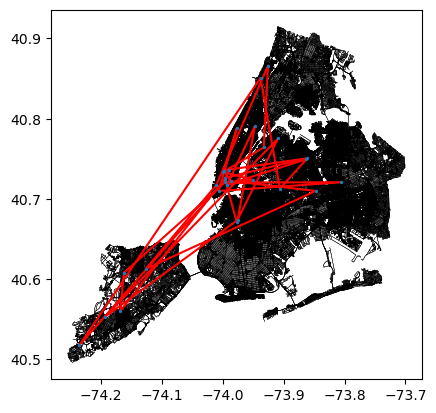

In [48]:
# Plot the random route
fig, ax = plt.subplots()


place_roads_edges.plot(ax = ax, linewidth = 0.3, color = 'black', zorder = 1)
ax.plot(all_long_ordered, all_lat_ordered, color='red', zorder = 2)

ax.scatter(all_long_ordered, all_lat_ordered, s = 2, zorder = 3)
plt.show()

In [49]:
ax.scatter( all_long_ordered, all_lat_ordered, zorder = 3)
plt.show()

In [50]:
# Print route length
route_length = 0
for i in range(len(nodes_ordered)-1):
    length = nx.shortest_path_length(place_roads, nodes_ordered[i], nodes_ordered[i+1], weight="length")
    route_length += length
print(route_length) 

496567.48100000015


## Method 2: Greedy
Now, let's try to choose nodes more intelligently: start at a random node again, but instead of choosing a random node each time, always choose the node closest to the current node each time.

Again, draw the path on the map and print its length.

In [75]:
# Select 30 ice cream shops
import random
sample_ice_cream = place_ice_cream.sample(n=30, random_state=42)

sample_ice_cream = sample_ice_cream.to_crs("epsg:3857")
sample_ice_cream["geometry"] = sample_ice_cream.geometry.centroid
sample_ice_cream = sample_ice_cream.to_crs("epsg:4326")

ice_cream_nodes = ox.distance.nearest_nodes(place_roads, sample_ice_cream.geometry.x, sample_ice_cream.geometry.y)
ice_cream_nodes

[8262308486,
 7779545035,
 10769394059,
 4150448089,
 9550791810,
 42870183,
 8952423311,
 5490138253,
 8699239244,
 42978254,
 9789356713,
 10770328374,
 2504466035,
 6330518858,
 10120035872,
 9893390525,
 7465391419,
 8309479003,
 9242368788,
 2611395793,
 6369613044,
 8304497518,
 42892833,
 9759657447,
 7465399875,
 7570756477,
 7779995675,
 42440284,
 10650749604,
 4320194254]

In [76]:
# Calculate shortest-path matrix (or use the one you developed earlier)
shortest_path_matrix = np.zeros([len(ice_cream_nodes),len(ice_cream_nodes)])

for idx_i, orig in enumerate(ice_cream_nodes):
#enumerate returns the index and the node id
    shortest_paths = nx.single_source_dijkstra_path_length(place_roads, orig, weight='length')
    for idx_j, dest in enumerate(ice_cream_nodes):
        shortest_path_matrix[idx_i, idx_j] = shortest_paths[dest]
shortest_path_matrix

array([[    0.   ,  8201.336, 33603.92 , 30379.584, 14335.075, 18648.747,
        16348.377, 27617.794,  6490.433, 24475.65 ,  6744.061,  1755.652,
         8564.113,  2562.389, 13262.494,  8096.141,  2155.499,  1339.566,
        10922.566,   991.596,  2513.823,  2505.981, 13383.82 ,  9861.118,
         2082.854,  7835.309, 38346.83 ,  3345.297, 14877.989,   239.803],
       [ 8223.618,     0.   , 40546.326, 37321.99 ,  7502.132, 17306.816,
         9448.232, 34560.2  ,  3181.798, 31418.056,  9892.62 ,  8842.21 ,
         6256.457,  9378.336, 10720.231, 14925.05 ,  8908.263,  8439.371,
         5735.624,  7292.85 ,  9317.912, 10402.577, 10660.786, 12179.848,
         9153.661, 14664.218, 45289.236, 10756.766, 14872.864,  8422.35 ],
       [33226.38 , 40369.962,     0.   ,  3376.079, 47362.933, 41600.126,
        49379.757,  8554.989, 39499.283, 10878.355, 32872.99 , 31926.488,
        38080.697, 31167.509, 40474.33 , 26415.415, 32207.768, 32291.403,
        40439.15 , 33391.602, 31289.

In [77]:
# Create greedy TSP route
import random 
n = len(ice_cream_nodes)
route = list(range(n))
start = random.randint(route[0], route[-1])
route.remove(start)

remaining = route

ordered_nodes = [start]
current_node = start
next_node = None

remaining

while remaining != []:
    
    smallest_dist = float("inf")
    
    for i in remaining:
        dist = shortest_path_matrix[current_node, i]
        if dist < smallest_dist:
            smallest_dist = dist
            next_node = i
    remaining.remove(next_node)
    ordered_nodes.append(next_node)
    current_node = next_node
          

ordered_nodes.append(start)




In [78]:
# Prepare route coordinates for plotting
nodes_with_id_ordered = []
for i in ordered_nodes:
    node_id = ice_cream_nodes[i]
    nodes_with_id_ordered.append(node_id)

all_lat_ordered = []
all_long_ordered = []
for i in nodes_with_id_ordered:
    info = place_roads.nodes[i]
    lat = info['y'] 
    long = info ['x']
    all_lat_ordered.append(lat)
    all_long_ordered.append(long)

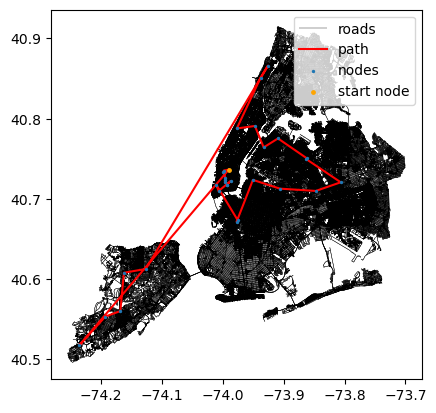

In [83]:
# Plot the greedy
fig, ax = plt.subplots()


place_roads_edges.plot(ax = ax, linewidth = 0.3, color = 'black', zorder = 1, alpha = 0.9, label = 'roads') # why is the legend showing it as grey
ax.plot(all_long_ordered, all_lat_ordered, color='red', zorder = 2, label = 'path')

ax.scatter(all_long_ordered, all_lat_ordered, s = 2, zorder = 3, label = 'nodes')

ax.scatter(all_long_ordered[-1], all_lat_ordered[-1], c = 'orange', s = 6, zorder = 4, label = 'start node')

ax.legend()
plt.show()


In [71]:
# Print route length
route_length = 0
for i in range(len(nodes_with_id_ordered)-1):
    length = nx.shortest_path_length(place_roads, nodes_with_id_ordered[i], nodes_with_id_ordered[i+1], weight="length")
    route_length += length

route_length += nx.shortest_path_length(place_roads, nodes_with_id_ordered[-1], nodes_with_id_ordered[0], weight="length")
print(route_length) 



161692.93199999997


## Method 3: Random with 2-opt swapping (Optional Challenging)

You may have noticed that both paths contain a lot of edges that cross each other, which is nonideal. However, there exists an algorithm to remove all the paths that cross each other from a Hamiltonian cycle: the [2-opt](https://en.wikipedia.org/wiki/2-opt) algorithm. We can use that to our advantage here.

Start by generating a random Hamiltonian cycle like in method 1, but this time, use the 2-opt algorithm to optimize it further. Again, draw it on the map and print its length.

In [ ]:
# Select 30 ice cream shops — same as Method 1 and Method 2
# Select 30 ice cream shops

import random
sample_ice_cream = place_ice_cream.sample(n=30, random_state=42)

sample_ice_cream = sample_ice_cream.to_crs("epsg:3857")
sample_ice_cream["geometry"] = sample_ice_cream.geometry.centroid
sample_ice_cream = sample_ice_cream.to_crs("epsg:4326")

ice_cream_nodes = ox.distance.nearest_nodes(place_roads, sample_ice_cream.geometry.x, sample_ice_cream.geometry.y)
ice_cream_nodes

In [ ]:
# Calculate shortest-path matrix — same as Method 1 and Method 2

shortest_path_matrix = np.zeros([len(ice_cream_nodes),len(ice_cream_nodes)])

for idx_i, orig in enumerate(ice_cream_nodes):
#enumerate returns the index and the node id
    shortest_paths = nx.single_source_dijkstra_path_length(place_roads, orig, weight='length')
    for idx_j, dest in enumerate(ice_cream_nodes):
        shortest_path_matrix[idx_i, idx_j] = shortest_paths[dest]
shortest_path_matrix

In [80]:
# Create initial random route — similar to Method 1

n = len(ice_cream_nodes)
route = list(range(n))
np.random.shuffle(route)
route.append(route[0])
route


[28,
 12,
 0,
 4,
 13,
 7,
 29,
 2,
 10,
 26,
 18,
 21,
 23,
 25,
 16,
 15,
 9,
 22,
 8,
 27,
 11,
 20,
 5,
 1,
 17,
 19,
 3,
 6,
 24,
 14,
 28]

In [ ]:
# Improve the random route using 2-opt swapping



In [ ]:
# Prepare route coordinates for plotting — similar to Method 1 and Method 2


In [ ]:
# Plot the 2-opt route — similar to Method 1 and Method 2


In [ ]:
# Print route length — similar to Method 1 and Method 2


## Method 4: Open-ended( Optional Challenging)

Although the 2-opt swaps reduce the length of the Hamiltonian cycle by quite a lot, they almost never provide the optimal solution. See if you can use another method to produce a Hamiltonian cycle shorter than the one you got with method 3. Some options to explore include:

- [3-opt](https://en.wikipedia.org/wiki/3-opt)
- [Multi-fragment algorithm](https://en.wikipedia.org/wiki/Multi-fragment_algorithm) with 2- or 3-opt swapping
- [Simulated annealing](https://en.wikipedia.org/wiki/Simulated_annealing)

The [TSP Wikipedia page](https://en.wikipedia.org/wiki/Travelling_salesman_problem) has many other algorithms that could be of use to you as well.


In [ ]:
# Select 30 ice cream shops — same as Method 1, Method 2, and Method 3



In [ ]:
# Calculate the shortest road-network distance between every pair of selected ice cream shops



In [ ]:
# create a a random TSP route



In [ ]:
# Create a 2-opt route first so Method 4 can compare against Method 3



In [ ]:
# Improve the 2-opt route using 3-opt swapping




In [ ]:
# Convert route indexes back to original road-network node IDs


In [ ]:
#plot


In [ ]:
# calculate route length
